In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np


In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
data.head()

,config_id,index,performance,hp_config.clip_eps,hp_config.ent_coef,hp_config.gae_lambda,hp_config.learning_rate,hp_config.max_grad_norm,hp_config.minibatch_size,hp_config.normalize_advantage,...,hp_config.initial_epsilon,hp_config.learning_starts,hp_config.target_epsilon,hp_config.use_target_network,hp_config.buffer_alpha,hp_config.buffer_beta,hp_config.buffer_epsilon,hp_config.target_update_interval,hp_config.reward_scale,hp_config.tau
0,0,0,4742.1875,0.274407,0.357595,0.920492,0.000530,0.423655,256.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,10,6640.6250,0.191721,0.395863,0.905726,0.000692,0.925597,128.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,20,2000.0000,0.389078,0.435006,0.995626,0.009904,0.461479,512.0,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,30,1718.7500,0.472334,0.260924,0.882891,0.000021,0.774234,256.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,40,0.0000,0.306048,0.308467,0.988655,0.002565,0.359508,256.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

# 1. Normalization

In [5]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False)["_seed_avg"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

data["normed_performance_seedavg"] = data.groupby("env_name", group_keys=False)["_seed_avg"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# 1a). Filter Bad environments

In [6]:
# remove trash environments because they kill the cross-environment ranking later
bad_envs = ["cc_mountain_car", "minigrid_unlock"]
data = data[~data["env_name"].isin(bad_envs)]

# 2. Adjusted THC

In [7]:
perf_column = "performance"
# alternative: "last_performance", "normed_performance", "normed_performance_per_alg", "normed_performance_per_alg_seedavg"

In [8]:
def compute_rankings_binary(mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    # Step 1: Sort by upper bound
    r_idx = np.argsort(mu + sigma)
    mu_sorted = mu[r_idx]
    sigma_sorted = sigma[r_idx]
    n = len(mu)
    ranks = np.zeros(n)

    # Precompute bounds
    upper_bounds = mu_sorted + sigma_sorted
    lower_bounds = mu_sorted - sigma_sorted

    for j in range(n):
        # Step 5: uj = binary_search(lower_bounds, mu[j] + sigma[j])
        uj = np.searchsorted(lower_bounds, mu[j] + sigma[j], side='right')
        # Step 6: lj = binary_search(upper_bounds, mu[j] - sigma[j])
        lj = np.searchsorted(upper_bounds, mu[j] - sigma[j], side='left')
        # Step 8: Average rank
        ranks[j] = (lj + uj) / 2

    # Reorder ranks to original order
    ranks_final = np.zeros(n)
    ranks_final[r_idx] = ranks
    return ranks_final

In [9]:
def bootstrap_ci(data, n_boot=100, ci=95):
    boot_means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))
    mean = np.mean(boot_means)
    half_width = (np.percentile(boot_means, 97.5) - np.percentile(boot_means, 2.5)) / 2
    return mean, half_width

In [10]:
rank_dfs = {}
envs = data["env_name"].unique()
algos = data["algorithm"].unique()

for algo in algos:
    rank_df_data = {}
    for env in envs:

        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]

        mu, sigma = [], []

        for config_id in subset["config_id"].unique():
            config_subset = subset[subset["config_id"] == config_id]
            mean, ci_half_width = bootstrap_ci(config_subset[perf_column].values)
            mu.append(mean)
            sigma.append(ci_half_width)
        
        mu = np.array(mu)
        sigma = np.array(sigma)

        # sigma = sigma / 4       # make smaller intervals for overlap

        ranks_i = compute_rankings_binary(mu, sigma)

        if len(ranks_i) > 0:
            rank_df_data[env] = ranks_i

    # print(rank_df_data)
    rank_dfs[algo] = pd.DataFrame(rank_df_data)

# give index column the name "config_id"
for algo in algos:
    rank_dfs[algo].index.name = "config_id"


In [11]:
thc_values = {}
for algo in algos:
    df = rank_dfs[algo]
    df.insert(0, "ptp", df.max(axis=1) - df.min(axis=1))

    # normed ptp is obtained by dividing through the number of rows - 1
    # insert this new column right after ptp
    df.insert(1, "normed_ptp", df["ptp"] / (len(df) - 1) if len(df) > 1 else 0)

    thc_values[algo] = {
        "mean_normed_ptp": df["normed_ptp"].mean(),
        "std_dev_normed_ptp": df["normed_ptp"].std()
    }

In [12]:
# rank_dfs["ppo"].head()

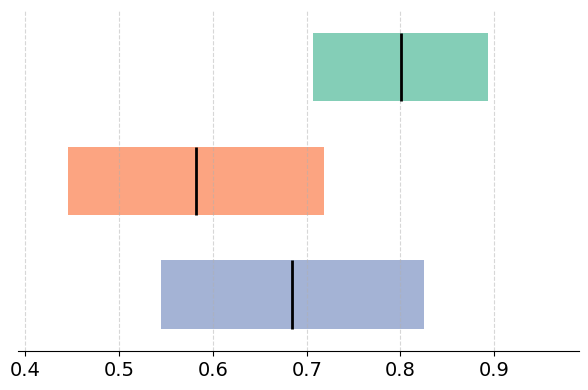

In [13]:
# Recreate the plot for thc_values, remove black outline, sort PPO, DQN, SAC

algo_rows = []
for algo in ["ppo", "dqn", "sac"]:  # enforce order
    if algo in thc_values:
        mean_thc = thc_values[algo]["mean_normed_ptp"]
        std_thc = thc_values[algo]["std_dev_normed_ptp"]
        algo_rows.append({"algorithm": algo.upper(), "thc": mean_thc, "thc_std": std_thc})

algo_df = pd.DataFrame(algo_rows)

# sort algo_df in order ["ppo", "dqn", "sac"]
algo_df = algo_df.set_index("algorithm")
algo_df = algo_df.reindex(["SAC", "DQN", "PPO"])
algo_df = algo_df.reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2")
col_map = {"PPO": palette[0], "DQN": palette[1], "SAC": palette[2]}

y = np.arange(len(algo_df))
height = 0.6
for i, row in enumerate(algo_df.itertuples(index=False)):
    left = row.thc - row.thc_std
    width = row.thc_std * 2
    rect = plt.Rectangle((left, i - height/2), width, height,
                         facecolor=col_map[row.algorithm], edgecolor=None, linewidth=0, alpha=0.8)
    ax.add_patch(rect)
    ax.vlines(row.thc, i - height/2, i + height/2, color="black", linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels([])
ax.set_xlabel("")
ax.set_xlim(algo_df["thc"].min() - algo_df["thc_std"].max() -0.05, algo_df["thc"].max() + algo_df["thc_std"].max() + 0.05)
ax.set_ylim(-0.5, len(algo_df) - 0.5)
ax.tick_params(axis="x", labelsize=14) 

# style
ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

ax.set_title("")
plt.tight_layout()
# plt.rcParams['xtick.labelsize'] = 14
plt.savefig("_figures/adjusted_THC.pdf", bbox_inches='tight')

## Pretty much the same picture as if we use the averaged THC over all hyperparameters as in the THC paper

# 3. With column "last performance"

In [14]:
perf_column = "last_performance"

In [15]:
rank_dfs = {}
envs = data["env_name"].unique()
algos = data["algorithm"].unique()

for algo in algos:
    rank_df_data = {}
    for env in envs:

        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]

        mu, sigma = [], []

        for config_id in subset["config_id"].unique():
            config_subset = subset[subset["config_id"] == config_id]
            mean, ci_half_width = bootstrap_ci(config_subset[perf_column].values)
            mu.append(mean)
            sigma.append(ci_half_width)
        
        mu = np.array(mu)
        sigma = np.array(sigma)

        # sigma = sigma / 4       # make smaller intervals for overlap

        ranks_i = compute_rankings_binary(mu, sigma)

        if len(ranks_i) > 0:
            rank_df_data[env] = ranks_i

    # print(rank_df_data)
    rank_dfs[algo] = pd.DataFrame(rank_df_data)

# give index column the name "config_id"
for algo in algos:
    rank_dfs[algo].index.name = "config_id"

In [16]:
thc_values = {}
for algo in algos:
    df = rank_dfs[algo]
    df.insert(0, "ptp", df.max(axis=1) - df.min(axis=1))

    # normed ptp is obtained by dividing through the number of rows - 1
    # insert this new column right after ptp
    df.insert(1, "normed_ptp", df["ptp"] / (len(df) - 1) if len(df) > 1 else 0)

    thc_values[algo] = {
        "mean_normed_ptp": df["normed_ptp"].mean(),
        "std_dev_normed_ptp": df["normed_ptp"].std()
    }

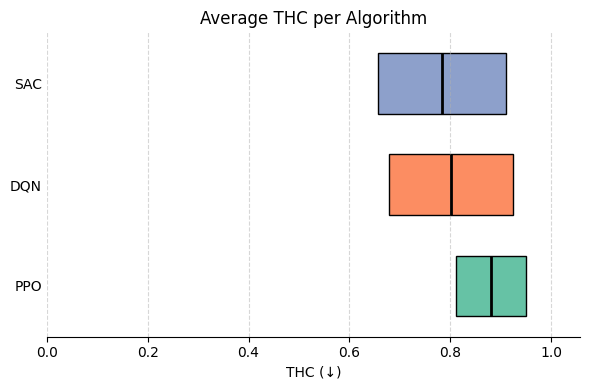

In [17]:
# Recreate the plot for thc_values

algo_rows = []
for algo in algos:
    if algo in thc_values:
        mean_thc = thc_values[algo]["mean_normed_ptp"]
        std_thc = thc_values[algo]["std_dev_normed_ptp"]
        algo_rows.append({"algorithm": algo.upper(), "thc": mean_thc, "thc_std": std_thc})

algo_df = pd.DataFrame(algo_rows).set_index("algorithm").loc[["PPO", "DQN", "SAC"]].reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2")
col_map = {"PPO": palette[0], "DQN": palette[1], "SAC": palette[2]}

y = np.arange(len(algo_df))
height = 0.6
for i, row in enumerate(algo_df.itertuples(index=False)):
    left = row.thc - row.thc_std
    width = row.thc_std * 2
    rect = plt.Rectangle((left, i - height/2), width, height,
                         facecolor=col_map[row.algorithm], edgecolor="black", linewidth=1)
    ax.add_patch(rect)
    ax.vlines(row.thc, i - height/2, i + height/2, color="black", linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels(algo_df["algorithm"])
ax.set_xlabel("THC (↓)")
ax.set_xlim(0, algo_df["thc"].max() + algo_df["thc_std"].max() + 0.05)
ax.set_ylim(-0.5, len(algo_df) - 0.5)

# style
ax.grid(axis="x", linestyle="--", alpha=0.5, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.title("Average THC per Algorithm")
plt.tight_layout()

# 3. Kendall W based on the same ranks 

In [18]:
alg = data["algorithm"].unique()[0]

kendall_w_values = {}

# drop ptp and normed_ptp columns from rank_dfs[alg]
for algo in algos:
    rank_dfs[algo] = rank_dfs[algo].drop(columns=["ptp", "normed_ptp"], errors="ignore")

    # create column R_j which is the mean over rows of the rank_dfs[algo]
    rank_dfs[algo]["R_j"] = rank_dfs[algo].sum(axis=1)
    R_j = rank_dfs[algo]["R_j"].values
    R_bar = R_j.mean()

    S = ((R_j - R_bar) ** 2).sum()

    J = len(R_j)
    M = len(rank_dfs[algo].columns) - 1  # exclude R_j column
    # print(M, J)

    W = 12 * S / (M**2 * J * (J**2 - 1))

    kendall_w_values[algo] = W

print("Kendall's W values:")
for algo, W in kendall_w_values.items():
    print(f"{algo.upper()}: {W:.4f}")   

Kendall's W values:
PPO: 0.0584
DQN: 0.0885
SAC: 0.1181
